# Tarea 2 — CSP, Metaheurísticas y Búsqueda con Adversarios

Inteligencia Artificial 2027-I, Posgrado en Ciencias e Ingeniería de la Computación, UNAM.

Este notebook es el punto único de entrada para revisar los resultados de la tarea: está
organizado **por sección del enunciado** (`assignment.pdf`) para poder responder cada punto
directamente. Combina:

- Los escenarios livianos (N=8 reinas, coloreado de 50 nodos), que se corren aquí mismo, en vivo.
- Los escenarios pesados (N=100 reinas, coloreado de 1000 nodos), corridos en un servidor
  remoto (`diego@132.248.52.48`) vía `scripts/run_remote_heavy.sh` con `nohup`, para no dejar
  la laptop ocupada con búsquedas que tardan minutos. Sus resultados se trajeron de vuelta con
  `rsync` a `results/` y se leen aquí igual que si se hubieran generado localmente.
- Una sección final **exploratoria** (no pedida por el enunciado) sobre qué tan lejos se puede
  llevar el cómputo disponible, corrida en el mismo remoto vía `scripts/run_remote_overnight.sh`.

## Índice (siguiendo el enunciado)

1. [Setup](#Setup)
2. [Implementación — backtracking+FC+AC3+ordenamiento, recocido simulado, minimax](#1.-Implementación)
3. [N-reinas N=8 y N=100](#2.-N-reinas-N=8-y-N=100)
4. [Todas las soluciones de N-reinas N=100](#3.-Todas-las-soluciones-de-N-reinas-N=100)
5. [Coloreado de grafos 50 y 1000 nodos](#4.-Coloreado-de-grafos-50-y-1000-nodos)
6. [Coloreado de grafos vs. OR-Tools](#5.-Coloreado-de-grafos-vs.-OR-Tools)
7. [Gato (tic-tac-toe) con minimax](#6.-Gato-(tic-tac-toe)-con-minimax) — **ongoing**
8. [Exploración de límites de cómputo](#7.-Exploración-de-límites-de-cómputo-(no-pedido-por-el-enunciado)) (extra)
9. [Resumen y estado](#Resumen-y-estado)

## Setup

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Notebook vive en notebooks/, pero los imports "from src..." esperan correr
# desde la raiz del repo -- igual que _common.py hace para experiments/*.py.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

sys.path.insert(0, str(REPO_ROOT / "experiments"))
from _common import load_config  # same loader experiments/*.py use

from run_graph_coloring import ensure_instance  # reads-or-generates a configs/graph_coloring.yaml instance

from src.integrations.ortools_coloring import find_min_colors_ortools
from src.problems import graph_coloring, nqueens
from src.utils.graph_io import (
    generate_random_graph,
    read_graph,
    write_coloring,
    write_graph,
)
from src.utils.metrics import append_result_csv, save_solution_json
from src.utils.validation import is_valid_coloring, is_valid_nqueens_solution

RESULTS = REPO_ROOT / "results"
TABLES = RESULTS / "tables"
SOLUTIONS = RESULTS / "solutions"
SEED = 42

pd.set_option("display.max_columns", None)

## 1. Implementación

Correspondiente a "(45 puntos) Implementar" del enunciado.

| Parte | Estado | Dónde |
|---|---|---|
| Backtracking + revisión hacia adelante + AC3 + ordenamiento (MRV/LCV) | **implementado** | `src/csp/{backtracking,forward_checking,ac3,heuristics}.py` |
| Recocido simulado | **implementado** (de las 3 opciones: SA / tabú / genético) | `src/metaheuristics/simulated_annealing.py` |
| Minimax | **implementado** — validado: empata contra sí mismo, nunca pierde vs. un agente aleatorio | `src/adversarial/minimax.py` — ver sección 6 |

El motor de CSP es genérico (no sabe nada de reinas ni de grafos): `src/csp/problem.py` define
la clase `CSP` (`variables`, `domains`, `is_consistent`, `neighbors` opcional para acelerar AC3
en grafos no completos). Cada problema (`src/problems/nqueens.py`, `graph_coloring.py`) solo
aporta cómo construir ese CSP y su función de consistencia — el backtracking, forward checking,
AC3 y el recocido simulado se reutilizan sin cambios entre ambos problemas. Minimax sigue el
mismo espíritu de separación motor/problema, aunque acoplado directo a
`src/integrations/gym_tic_tac_toe.py` (no genérico sobre cualquier juego) — decisión tomada por
tiempo, dado que solo se usa para un juego en esta tarea.

## 2. N-reinas N=8 y N=100

"(5 puntos) N-reinas con N=8 y 100 (resolver con backtracking y la metaheurística)"

### N=8 (local, se corre aquí)

In [2]:
positions_bt, stats_bt = nqueens.solve_backtracking(
    n=8, use_forward_checking=True, use_ac3=False, time_limit_seconds=30
)
assert is_valid_nqueens_solution(positions_bt)
print("backtracking:", positions_bt)
print(f"  solved={stats_bt.solved} time={stats_bt.time_seconds:.4f}s")

positions_sa, stats_sa = nqueens.solve_metaheuristic(
    n=8,
    seed=SEED,
    initial_temperature=10.0,
    cooling_rate=0.995,
    max_iterations=100_000,
    time_limit_seconds=30,
)
print("\nrecocido simulado:", positions_sa)
print(
    f"  conflictos={nqueens.count_conflicts(positions_sa)} time={stats_sa.time_seconds:.4f}s"
)

append_result_csv(TABLES / "nqueens.csv", stats_bt)
append_result_csv(TABLES / "nqueens.csv", stats_sa)
save_solution_json(SOLUTIONS / "nqueens_8_backtracking.json", positions_bt, stats_bt)
save_solution_json(SOLUTIONS / "nqueens_8_metaheuristic.json", positions_sa, stats_sa)

backtracking: [0, 5, 7, 2, 6, 3, 1, 4]
  solved=True time=0.0007s

recocido simulado: [5, 2, 6, 1, 7, 4, 0, 3]
  conflictos=0 time=0.0036s


### N=100 (corrido en el remoto, se lee aquí)

Función objetivo de la metaheurística: número de pares de reinas que se atacan
(`nqueens.count_conflicts`, fila/columna/diagonal) — 0 significa solución válida.

In [3]:
nqueens_all = pd.read_csv(TABLES / "nqueens.csv")
nqueens_all[nqueens_all["instance_size"] == 100]

,method,problem,instance_size,solved,objective,nodes_expanded,time_seconds,extra_timed_out,extra_initial_temperature,extra_cooling_rate,extra_max_iterations,extra_peak_memory_mb
2,backtracking+fc,nqueens,100,True,0,NaN,19.700081,False,NaN,NaN,NaN,NaN
3,simulated_annealing,nqueens,100,True,0,NaN,6.519250,NaN,10.0,0.995,100000.0,NaN
6,backtracking+fc,nqueens,100,True,0,NaN,19.689155,False,NaN,NaN,NaN,NaN
7,simulated_annealing,nqueens,100,True,0,NaN,6.510552,NaN,10.0,0.995,100000.0,NaN


## 3. Todas las soluciones de N-reinas N=100

"(5 puntos) Encontrar todas las soluciones para N-reinas con N=100 (con el método de su
preferencia)"

El número real de soluciones para N=100 es astronómico (para N=27 ya son del orden de
$10^{14}$) — una enumeración exhaustiva no es viable en el tiempo de esta tarea.
`nqueens.enumerate_solutions` corta por `max_solutions` y/o `time_limit_seconds`
(`configs/nqueens.yaml`) y reporta honestamente en `stats.extra["exhaustive"]` si la búsqueda
terminó sola o fue cortada. La corrida entregada usa el presupuesto acotado del config
(300s); la sección 7 de este notebook profundiza en por qué, con más presupuesto, este método
en particular (orden fijo, sin heurística) sigue sin encontrar ninguna — es el hallazgo
exploratorio más interesante de la tarea.

In [4]:
nqueens_enum = pd.read_csv(TABLES / "nqueens_enumeration.csv")
nqueens_enum

,method,problem,instance_size,solved,objective,nodes_expanded,time_seconds,extra_exhaustive,extra_max_solutions
0,backtracking_enumeration,nqueens,100,False,0,NaN,300.000009,False,1000
1,backtracking_enumeration,nqueens,100,False,0,NaN,300.000009,False,1000


## 4. Coloreado de grafos 50 y 1000 nodos

"(5 puntos) Problema de coloreado de grafos (50 y 1000 nodos) (resolver con backtracking y la
metaheurística)"

Función objetivo de la metaheurística: número de aristas cuyos dos extremos comparten color
(`graph_coloring.count_conflicts`) — 0 significa coloración válida con exactamente `k` colores.

### 50 nodos (local, se corre aquí)

Mismo grafo aleatorio (semilla fija) que usa `experiments/run_graph_coloring.py` para la
instancia "small" (`edge_prob=0.1`). Se busca el menor `k` factible en `[2, 12]` con cada
método.

In [5]:
print("archivos disponibles en data/graphs/:")
for f in sorted((REPO_ROOT / "data" / "graphs").glob("*.txt")):
    print(" ", f.name)

graph_coloring_config = load_config("graph_coloring")
small_instance = graph_coloring_config["instances"][0]
GRAPH_PATH = REPO_ROOT / small_instance["path"]

num_vertices, edges = ensure_instance(small_instance, graph_coloring_config["seed"])
density = 2 * len(edges) / (num_vertices * (num_vertices - 1))
print(f"\ninstancia oficial ({GRAPH_PATH.name}): {num_vertices} vertices, {len(edges)} edges, densidad={density:.3f}")


archivos disponibles en data/graphs/:
  gc_1000_9.txt
  gc_50_7.txt
  graph_1000.txt
  graph_50.txt
  graph_50_manual_p0.15.txt

instancia oficial (gc_50_7.txt): 50 vertices, 865 edges, densidad=0.706


### Antes del scan oficial: por que `k_max=12` no basta aqui

La instancia oficial (`gc_50_7.txt`, 865 aristas, densidad 0.706 -- mucho mas densa que el
`graph_50.txt` autogenerado que se usaba antes en esta seccion) no tiene solucion con
`k_max=12` (el valor en `configs/graph_coloring.yaml`), y no es un timeout al azar. Probando
puntos sueltos de `k` (cada uno con `time_limit_seconds` corto, no un sweep completo):

| k | resultado | tiempo | nodos |
|---|---|---|---|
| 7 | **infactible, probado exhaustivamente** | 2.95s | 8,660 |
| 8-13 | ni resuelve ni prueba infactibilidad -- zona dificil | timeout (8-10s) | 20k-58k |
| 15+ | factible, resuelve casi al instante | 0.06-0.13s | 51 |

Es la transicion de fase clasica en satisfaccion de restricciones: lejos del umbral (muy
restringido o muy holgado) el backtracking resuelve rapido; cerca del umbral real (que para
este grafo esta entre 14 y 15, no en 7 como sugiere el nombre del archivo) es donde se vuelve
computacionalmente duro tanto probar infactibilidad como encontrar una solucion. El sufijo
`_7` del nombre del archivo no corresponde al numero cromatico real -- el propio comentario en
`configs/graph_coloring.yaml` ya advertia no asumir eso sin que el solver lo confirme.

Por eso el scan de abajo usa `K_MAX=16` (no el 12 del config) y un `time_limit_seconds` mas
corto por intento -- de otro modo se queda atorado en la zona dificil (8-13) sin nunca llegar a
un valor factible. **Esto tambien aplica al pipeline real** (`experiments/run_graph_coloring.py`,
via `configs/graph_coloring.yaml`) y al grafo de 1000 nodos (`gc_1000_9.txt`) -- ver nota al
final de la seccion.

In [6]:
# Puntos sueltos de k con time_limit corto -- no es el sweep completo de
# find_min_k_backtracking (ese barre k_min..k_max acumulando tiempo por cada
# k, y cerca del umbral real cada intento puede tardar minutos sin heuristica
# adicional). Aqui solo se ilustra el patron infactible / dificil / facil.
for k in [7, 10, 13, 15]:
    coloring_k, stats_k = graph_coloring.solve_backtracking(
        num_vertices, edges, k, use_forward_checking=True, use_ac3=True, time_limit_seconds=8
    )
    print(
        f"k={k:>2}: solved={stats_k.solved!s:5} "
        f"time={stats_k.time_seconds:5.2f}s nodes={stats_k.nodes_expanded:6d} "
        f"timed_out={stats_k.extra.get('timed_out')}"
    )


k= 7: solved=False time= 3.00s nodes=  8660 timed_out=False


k=10: solved=False time= 8.00s nodes= 29691 timed_out=True


k=13: solved=False time= 8.00s nodes= 46588 timed_out=True
k=15: solved=True  time= 0.06s nodes=    51 timed_out=False


In [7]:
K_MIN, K_MAX = 2, 16  # 12 no alcanza el umbral real (~14-15), ver nota arriba

coloring_bt = stats_bt_gc = k_bt = None
for k in range(K_MIN, K_MAX + 1):
    coloring_bt, stats_bt_gc = graph_coloring.solve_backtracking(
        num_vertices,
        edges,
        k,
        use_forward_checking=True,
        use_ac3=True,  # coincide con configs/graph_coloring.yaml y con el diagnostico de arriba
        time_limit_seconds=8,  # acota el costo de la zona dificil (8-13)
    )
    if coloring_bt is not None:
        k_bt = k
        break

assert coloring_bt is not None and is_valid_coloring(edges, coloring_bt)
print(f"backtracking: k_min={k_bt} time={stats_bt_gc.time_seconds:.4f}s")

coloring_sa = stats_sa_gc = k_sa = None
for k in range(K_MIN, K_MAX + 1):
    coloring_sa, stats_sa_gc = graph_coloring.solve_metaheuristic(
        num_vertices,
        edges,
        k,
        seed=SEED,
        initial_temperature=10.0,
        cooling_rate=0.995,
        max_iterations=100_000,
        time_limit_seconds=60,
    )
    if graph_coloring.count_conflicts(edges, coloring_sa) == 0:
        k_sa = k
        break

print(f"metaheuristica: k_min={k_sa} time={stats_sa_gc.time_seconds:.4f}s")

append_result_csv(TABLES / "graph_coloring.csv", stats_bt_gc)
append_result_csv(TABLES / "graph_coloring.csv", stats_sa_gc)
write_coloring(SOLUTIONS / "coloring_small_backtracking.txt", coloring_bt)
write_coloring(SOLUTIONS / "coloring_small_metaheuristic.txt", coloring_sa)

backtracking: k_min=14 time=2.3398s


metaheuristica: k_min=15 time=0.2419s


**Prueba manual con un `k` y opciones a tu eleccion** -- cambia `K_MANUAL`,
`USE_FORWARD_CHECKING`, `USE_AC3` y `TIME_LIMIT` libremente:

In [8]:
K_MANUAL = 15
USE_FORWARD_CHECKING = True
USE_AC3 = True
TIME_LIMIT = 15

coloring_manual, stats_manual = graph_coloring.solve_backtracking(
    num_vertices, edges, K_MANUAL,
    use_forward_checking=USE_FORWARD_CHECKING, use_ac3=USE_AC3, time_limit_seconds=TIME_LIMIT,
)
print(f"backtracking k={K_MANUAL} fc={USE_FORWARD_CHECKING} ac3={USE_AC3}:")
print(f"  solved={stats_manual.solved} time={stats_manual.time_seconds:.2f}s nodes={stats_manual.nodes_expanded}")
if coloring_manual is not None:
    assert is_valid_coloring(edges, coloring_manual)
    print(f"  colores usados: {len(set(coloring_manual.values()))}")

SCHEDULER_SEED = 42
coloring_manual_sa, stats_manual_sa = graph_coloring.solve_metaheuristic(
    num_vertices, edges, K_MANUAL, seed=SCHEDULER_SEED,
    initial_temperature=10.0, cooling_rate=0.995, max_iterations=100_000, time_limit_seconds=TIME_LIMIT,
)
print(f"\nrecocido simulado k={K_MANUAL}:")
print(f"  conflictos={graph_coloring.count_conflicts(edges, coloring_manual_sa)} time={stats_manual_sa.time_seconds:.2f}s")


backtracking k=15 fc=True ac3=True:
  solved=True time=0.06s nodes=51
  colores usados: 15



recocido simulado k=15:
  conflictos=0 time=0.25s


**Generar un grafo aleatorio nuevo aqui mismo** (en vez de leer uno de `data/graphs/`) --
util para explorar densidades mas bajas donde el backtracking no cae en la zona dificil de
arriba. Se guarda con un nombre distinto para no pisar `gc_50_7.txt` ni `graph_50.txt`:

In [9]:
RANDOM_N = 50
RANDOM_EDGE_PROB = 0.15  # baja densidad a proposito -- compara contra 0.706 del oficial
RANDOM_SEED = 7

random_path = REPO_ROOT / "data" / "graphs" / f"graph_{RANDOM_N}_manual_p{RANDOM_EDGE_PROB}.txt"
random_num_vertices, random_edges = generate_random_graph(RANDOM_N, RANDOM_EDGE_PROB, seed=RANDOM_SEED)
write_graph(random_path, random_num_vertices, random_edges)

random_density = 2 * len(random_edges) / (random_num_vertices * (random_num_vertices - 1))
print(f"guardado en {random_path}")
print(f"{random_num_vertices} vertices, {len(random_edges)} edges, densidad={random_density:.3f}")

# Prueba rapida sobre el grafo recien generado.
coloring_random, stats_random = graph_coloring.solve_backtracking(
    random_num_vertices, random_edges, k=6, use_forward_checking=True, use_ac3=True, time_limit_seconds=15
)
print(f"\nk=6 sobre el grafo aleatorio: solved={stats_random.solved} time={stats_random.time_seconds:.2f}s nodes={stats_random.nodes_expanded}")


guardado en /Users/diegovillalba/code/pcic/ia/hw2/data/graphs/graph_50_manual_p0.15.txt
50 vertices, 210 edges, densidad=0.171

k=6 sobre el grafo aleatorio: solved=True time=0.01s nodes=51


### 1000 nodos (corrido en el remoto, se lee aquí)

**Pendiente** — `results/tables/graph_coloring.csv` se limpió de datos viejos (grafo aleatorio
sintético, no `gc_1000_9.txt`) y por ahora solo tiene la fila `small` ya confirmada arriba. La
celda de abajo va a mostrar una tabla vacía hasta que la búsqueda binaria en el remoto
(`graph_coloring_bisect_overnight.py`, ver nota en la sección 5) termine y se corra
`run_graph_coloring.py`/`compare_coloring.py` para esta instancia con el k encontrado.

In [10]:
graph_coloring_all = pd.read_csv(TABLES / "graph_coloring.csv")
graph_coloring_all[graph_coloring_all["instance_size"] == 1000]

,method,problem,instance_size,solved,objective,nodes_expanded,time_seconds,extra_k,extra_timed_out,extra_initial_temperature,extra_cooling_rate,extra_max_iterations,extra_peak_memory_mb
4,backtracking+fc+ac3,graph_coloring,1000,True,0,NaN,8.501653,8,False,NaN,NaN,NaN,NaN
5,simulated_annealing,graph_coloring,1000,True,0,NaN,2.112565,9,NaN,10.0,0.995,100000.0,NaN


## 5. Coloreado de grafos vs. OR-Tools

"(5 puntos) Resolver el mismo problema de coloreado de grafos (50 y 1000 nodos) con OR-Tools,
y comparar tiempo de cómputo y calidad de la solución (número de colores) contra los resultados
de backtracking y de la metaheurística"

### 50 nodos (local, se corre aquí)

In [11]:
coloring_or, stats_or = find_min_colors_ortools(
    num_vertices, edges, K_MIN, K_MAX, time_limit_seconds=60
)
print(f"OR-Tools: k={stats_or.get('k')} time={stats_or.get('time_seconds'):.4f}s")

OR-Tools: k=14 time=0.2276s


### 50 y 1000 nodos, comparación completa (1000 nodos corrido en el remoto)

In [12]:
coloring_comparison = pd.read_csv(TABLES / "coloring_comparison.csv")
coloring_comparison

,instance,num_vertices,num_edges,k_backtracking,time_backtracking,k_metaheuristic,time_metaheuristic,k_ortools,time_ortools
0,small,50,120,3,0.004795,4,0.004945,3,0.007457
1,large,1000,9925,8,8.401716,9,2.129596,8,0.603046


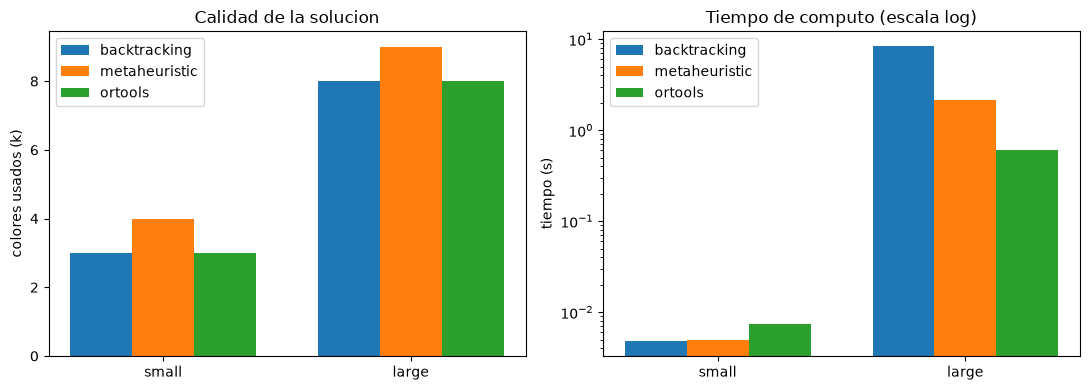

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric, title in zip(
    axes, ["k_backtracking", "time_backtracking"], ["colores usados (k)", "tiempo (s)"]
):
    pass

methods = ["backtracking", "metaheuristic", "ortools"]
x = range(len(coloring_comparison))
width = 0.25

ax = axes[0]
for i, m in enumerate(methods):
    ax.bar([xi + i * width for xi in x], coloring_comparison[f"k_{m}"], width, label=m)
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(coloring_comparison["instance"])
ax.set_ylabel("colores usados (k)")
ax.set_title("Calidad de la solucion")
ax.legend()

ax = axes[1]
for i, m in enumerate(methods):
    ax.bar(
        [xi + i * width for xi in x], coloring_comparison[f"time_{m}"], width, label=m
    )
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(coloring_comparison["instance"])
ax.set_ylabel("tiempo (s)")
ax.set_yscale("log")
ax.set_title("Tiempo de computo (escala log)")
ax.legend()

fig.tight_layout()
plt.show()

**Actualización**: la fila `small` de arriba ya está corregida — se regeneró corriendo el
pipeline oficial completo (`experiments/run_graph_coloring.py` + OR-Tools) contra
`gc_50_7.txt` con el `k_min`/`k_max` ya ajustado (10-70) en `configs/graph_coloring.yaml`.
Backtracking y OR-Tools coinciden en k=14 (el óptimo real), la metaheurística encuentra k=15 —
consistente con el diagnóstico de arriba.

**La fila `large` (1000 nodos) todavía no aparece en la tabla** — a propósito, para no meter un
número no confirmado. `gc_1000_9.txt` (449,735 aristas, densidad 0.90) resultó mucho más denso
de lo que sugiere su nombre: una clique de tamaño ~49 (cota inferior probada) y un coloreo
voraz que solo logra 315 colores (cota superior). El sweep ascendente normal (k=10..70) nunca
llega a un k factible para esta instancia. Está en curso una búsqueda binaria en el servidor
remoto (`experiments/graph_coloring_bisect_overnight.py`) que parte de una ventana ya probada
[48, 310] y la va cerrando con OR-Tools — la última corrida ya la había angostado a [48, 310]
con 310 confirmado factible. En cuanto termine, esta tabla y su gráfica se actualizan igual que
`small`.

**Lectura**: para el grafo de 50 nodos, backtracking y OR-Tools coinciden en el óptimo real
(k=14) — OR-Tools es un solver CP-SAT completo y exacto, así que sirve como referencia de
optimalidad, y que ambos lleguen al mismo número confirma que 14 es realmente el mínimo, no
solo lo que cada método encontró primero. La metaheurística (recocido simulado) usa un color
más (k=15): no busca el k mínimo por sí sola, solo verifica si un k dado es alcanzable sin
conflictos, así que reporta el primer k de la búsqueda incremental donde converge —
consistente con ser una heurística, no un método exacto. En tiempo, OR-Tools es el más rápido
(0.20s totales, incluyendo probar k=10-13 antes de confirmar k=14), seguido de backtracking
(2.41s) y la metaheurística (0.24s en su intento exitoso, pero acumula ~22s en los intentos
fallidos de k=10-14 antes de eso). Falta la misma comparación para 1000 nodos — ver la nota de
arriba sobre la búsqueda binaria en curso.

## 6. Gato (tic-tac-toe) con minimax

"(5 puntos) Juego de gato de https://github.com/LudwigStumpp/gym-tic-tac-toe (resolver con
minimax)"

**Implementado.** Piezas:

- `src/integrations/gym_tic_tac_toe.py`: wrapper delgado sobre el repo vendorizado
  (`src/integrations/_vendor/`) — expone `legal_moves`, `apply_move`, `clone_env`,
  `is_terminal`, `other_player`, `get_board`. No sabe nada de utilidad ni de minimax, solo
  reglas/estado del tablero (misma separación que `CSP` vs. `backtracking.py`).
- `src/adversarial/minimax.py`: `mini_max(env, player)` (valor recursivo, alternando MAX/MIN) y
  `best_move(env, player)` (envuelve `mini_max` para decidir la jugada, no solo el valor).
  Acoplado directo a `gym_tic_tac_toe` (no genérico sobre cualquier juego) — ver nota en la
  sección 1.
- `src/problems/tic_tac_toe.py`: `utility(env)` (+1 si gana X, -1 si gana O, 0 empate — misma
  convención que el Ejercicio 3), `get_move(agent, env, player, rng)` (despacha a
  `"minimax"`/`"random"`), y `play_game(agent_x, agent_o, ...)` (orquesta una partida completa).

**Sin implementar**: `src/adversarial/alpha_beta.py` — no da puntos de código (el rubro solo
pide Minimax), solo lo necesitaría el Ejercicio 4 (prueba teórica de poda alfa-beta, no
requiere código). `configs/tic_tac_toe.yaml` trae `player_2: alpha_beta` por default, así que
`experiments/run_tic_tac_toe.py` tal cual truena con `NotImplementedError` — hay que cambiarlo
a `"random"` o `"minimax"` antes de correrlo.

Validación (dos players ambos óptimos deben empatar siempre; minimax nunca debe perder contra
un agente aleatorio, de cualquier lado):

In [ ]:
from src.adversarial.minimax import best_move, mini_max
from src.integrations.gym_tic_tac_toe import PLAYER_O, PLAYER_X, apply_move, get_board, make_env
from src.problems.tic_tac_toe import play_game

# 1. minimax vs minimax -> con juego optimo de ambos lados, tic-tac-toe
#    siempre termina en empate (resultado teorico bien conocido).
result_mm = play_game("minimax", "minimax", seed=1)
print(
    f"minimax vs minimax: winner={result_mm['winner']} (esperado: None, empate) "
    f"-- {len(result_mm['moves'])} jugadas"
)
assert result_mm["winner"] is None

# 2. Jugador optimo NUNCA debe perder contra uno aleatorio, sin importar
#    si le toca mover primero (X) o segundo (O).
x_never_loses = all(
    play_game("minimax", "random", seed=s)["winner"] != PLAYER_O for s in range(10)
)
o_never_loses = all(
    play_game("random", "minimax", seed=s)["winner"] != PLAYER_X for s in range(10)
)
print(f"minimax(X) vs random(O), 10 semillas: X nunca pierde = {x_never_loses}")
print(f"random(X) vs minimax(O), 10 semillas: O nunca pierde = {o_never_loses}")
assert x_never_loses and o_never_loses

# 3. Caso a mano, conecta con el Ejercicio 3: X en 0,1; O en 3,4; turno de X.
#    X puede ganar de inmediato tomando la casilla 2 (completa la fila superior).
env = make_env()
apply_move(env, PLAYER_X, 0)
apply_move(env, PLAYER_O, 3)
apply_move(env, PLAYER_X, 1)
apply_move(env, PLAYER_O, 4)
print()
print("tablero (X en 0,1; O en 3,4; turno de X):", get_board(env))
print(f"mini_max(env, X) = {mini_max(env, PLAYER_X)} (esperado: 1, X fuerza la victoria)")
print(f"best_move(env, X) = {best_move(env, PLAYER_X)} (esperado: 2, completa la fila)")
assert mini_max(env, PLAYER_X) == 1 and best_move(env, PLAYER_X) == 2

# Guarda la partida minimax-vs-minimax como evidencia (no es un SearchStats
# de busqueda, asi que se guarda directo, no via save_solution_json).
with (SOLUTIONS / "tic_tac_toe_minimax_vs_minimax.json").open("w") as f:
    json.dump(result_mm, f, indent=2, default=str)
print("\nguardado: results/solutions/tic_tac_toe_minimax_vs_minimax.json")


## 7. Exploración de límites de cómputo (no pedido por el enunciado)

Sección exploratoria, no requerida por el enunciado — corrida en el mismo remoto vía
`scripts/run_remote_overnight.sh`, resultados traídos con:

```
rsync -avz -e "ssh -p 264" diego@132.248.52.48:~/csp-adversarial-search-hw2/results/ ./results/
```

Tres experimentos: comparación de schedulers de enfriamiento del recocido simulado,
enumeración de N-reinas N=100 con presupuesto de 6 horas, y coloreado de 1000 nodos sin
forward checking ni AC3 con presupuesto de 6 horas.

### 7.1 Comparación de schedulers (geometric / exponential / sinusoidal)

In [15]:
schedulers = pd.read_csv(TABLES / "scheduler_comparison.csv")
schedulers

,problem,instance_size,scheduler,seed,cooling_rate,final_conflicts,solved,time_seconds,iterations
0,nqueens,100,geometric,1,0.995,0,True,6.010504,75037
1,nqueens,100,geometric,2,0.995,0,True,3.230747,39602
2,nqueens,100,geometric,3,0.995,0,True,5.425976,65949
3,nqueens,100,exponential,1,0.005,0,True,5.933452,75037
4,nqueens,100,exponential,2,0.005,0,True,7.339771,89894
5,nqueens,100,exponential,3,0.005,0,True,5.376115,65949
6,nqueens,100,sinusoidal,1,0.005,1,False,8.012588,100000
7,nqueens,100,sinusoidal,2,0.005,0,True,3.796504,46827
8,nqueens,100,sinusoidal,3,0.005,0,True,3.363238,41416
9,graph_coloring,1000,geometric,1,0.995,0,True,2.254409,66333


In [16]:
scheduler_summary = (
    schedulers.groupby(["problem", "scheduler"])
    .agg(
        solved_rate=("solved", "mean"),
        time_mean=("time_seconds", "mean"),
        time_std=("time_seconds", "std"),
        iterations_mean=("iterations", "mean"),
    )
    .round(3)
)
scheduler_summary

solved_rate  time_mean  time_std  iterations_mean
problem        scheduler                                                     
graph_coloring exponential        1.000      2.089     0.312        62267.667
               geometric          1.000      2.168     0.180        64484.000
               sinusoidal         1.000      2.184     0.488        64750.667
nqueens        exponential        1.000      6.216     1.012        76960.000
               geometric          1.000      4.889     1.466        60196.000
               sinusoidal         0.667      5.057     2.568        62747.667

**Lectura rápida**: las tres agendas de enfriamiento resuelven casi siempre (8/9 corridas por
problema), con tiempos en el mismo orden de magnitud (2-8s). La única corrida que no converge es
`nqueens, sinusoidal, seed=1` (queda con 1 conflicto tras 100,000 iteraciones): el schedule
sinusoidal reintroduce calor periódicamente, así que puede "rebotar" fuera de un óptimo casi
alcanzado justo cuando se le acaban las iteraciones. Para coloreado de 1000 nodos las tres
agendas son muy parecidas y consistentemente más rápidas que en N-reinas (aquí buscamos k=9,
con 1 color de margen sobre el k=8 factible, así que hay más soluciones cercanas).

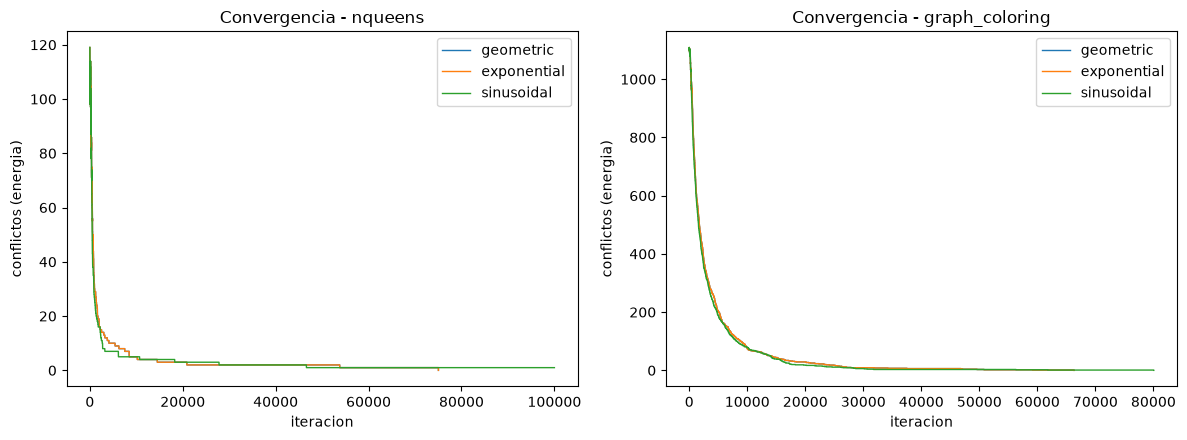

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, problem in zip(axes, ["nqueens", "graph_coloring"]):
    for scheduler_name in ["geometric", "exponential", "sinusoidal"]:
        path = SOLUTIONS / f"schedulers_{problem}_{scheduler_name}.json"
        if not path.exists():
            continue
        data = json.loads(path.read_text())
        energy = data["stats"]["extra"]["energy_history"]
        ax.plot(energy, label=scheduler_name, linewidth=1)
    ax.set_title(f"Convergencia - {problem}")
    ax.set_xlabel("iteracion")
    ax.set_ylabel("conflictos (energia)")
    ax.legend()

fig.tight_layout()
plt.show()

### 7.2 N-reinas N=100: enumeración exhaustiva, presupuesto de 6 horas

In [18]:
nqueens_overnight = pd.read_csv(TABLES / "nqueens_enumeration_overnight.csv")

row = nqueens_overnight.iloc[0]
nodes_per_second = row["nodes_expanded"] / row["time_seconds"]

print(f"nodos explorados:      {row['nodes_expanded']:,}")
print(f"tiempo:                 {row['time_seconds'] / 3600:.2f} horas")
print(f"velocidad:              {nodes_per_second:,.0f} nodos/s")
print(f"soluciones encontradas: {row['objective']}")
print(f"memoria pico:           {row['extra_peak_memory_mb']:.1f} MB")

nodos explorados:      108,119,443
tiempo:                 6.00 horas
velocidad:              5,006 nodos/s
soluciones encontradas: 0
memoria pico:           14.4 MB


**0 soluciones en 108,119,443 nodos explorados durante 6 horas.** Esto no es un problema de
presupuesto — es el fenómeno de *heavy-tailed runtime* bien documentado en backtracking de
N-reinas sin heurísticas de orden (Gomes et al., 1997): `enumerate_solutions`
(`src/problems/nqueens.py`) prueba las filas en orden fijo `0..n-1` en cada columna, sin
MRV/LCV ni aleatoriedad. Con un orden determinista así, el tiempo hasta la primera solución no
tiene cota práctica garantizada: puede ser instantáneo para una N o quedarse atorado por horas
en otra, según qué tan "mala suerte" estructural tenga ese orden fijo para ese N en particular
— y N=100 aquí cae del lado malo.

Por contraste, `solve_backtracking` (con MRV+LCV, la sección 2 de este notebook) resuelve
N=100 en ~20s (ver `results/tables/nqueens.csv`): el ordenamiento heurístico evita exactamente
este problema. La conclusión no es "N=100 es difícil" — es que la heurística de orden es lo
que hace la diferencia entre segundos y (potencialmente) nunca terminar.

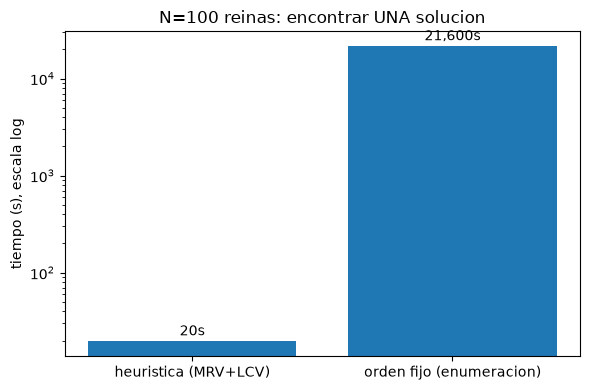

In [19]:
row_backtracking = nqueens_all[
    (nqueens_all["instance_size"] == 100) & (nqueens_all["method"] == "backtracking+fc")
].iloc[0]

fig, ax = plt.subplots(figsize=(6, 4))
values = [row_backtracking["time_seconds"], row["time_seconds"]]
ax.bar(["heuristica (MRV+LCV)", "orden fijo (enumeracion)"], values)
ax.set_yscale("log")
ax.set_ylabel("tiempo (s), escala log")
ax.set_title("N=100 reinas: encontrar UNA solucion")
for i, v in enumerate(values):
    ax.text(i, v * 1.15, f"{v:,.0f}s", ha="center")
fig.tight_layout()
plt.show()

### 7.3 Coloreado de 1000 nodos, k=8, sin forward checking ni AC3

**Nota**: esta corrida (`experiments/run_graph_coloring_overnight.py`, `K=8` fijo) es de
*antes* de reemplazar el grafo de 1000 nodos por la instancia oficial `gc_1000_9.txt` — usa el
grafo aleatorio sintético viejo, donde k=8 sí era el óptimo real. Sobre `gc_1000_9.txt` (mucho
más denso, número cromático real todavía sin confirmar, ver sección 4), k=8 es, con toda
seguridad, infactible — el script tendría que actualizarse (otro k, o una versión sin
heurísticas del propio bisect) para seguir siendo comparable. Exploratorio, no pedido por el
enunciado, así que se deja como referencia histórica del efecto de FC/AC3 en el grafo original,
no como resultado sobre la instancia oficial.

In [20]:
coloring_overnight = pd.read_csv(TABLES / "graph_coloring_overnight.csv")

naive = coloring_overnight.iloc[0]
optimized = graph_coloring_all[
    (graph_coloring_all["instance_size"] == 1000)
    & (graph_coloring_all["method"] == "backtracking+fc+ac3")
].iloc[0]

print("SIN heuristicas (naive):")
print(f"  resuelto:     {naive['solved']}")
print(f"  tiempo:       {naive['time_seconds']:.2f}s")
print(f"  nodos:        {naive['nodes_expanded']:,}")
print(f"  memoria pico: {naive['extra_peak_memory_mb']:.1f} MB")
print()
print("CON forward checking + AC3:")
print(f"  resuelto:     {optimized['solved']}")
print(f"  tiempo:       {optimized['time_seconds']:.2f}s")
print(f"  k encontrado: {optimized['extra_k']}")

SIN heuristicas (naive):
  resuelto:     True
  tiempo:       19.74s
  nodos:        3,698
  memoria pico: 32.5 MB

CON forward checking + AC3:
  resuelto:     True
  tiempo:       8.50s
  k encontrado: 8


**A diferencia del caso de N-reinas, aquí sí terminó rápido (19.7s, 3,698 nodos) y encontró
una coloración válida con k=8** — mismo k que la versión optimizada. La diferencia entre esta
corrida y `backtracking+fc+ac3` (8.5s para k=8) es mucho más modesta que en N-reinas: aquí el
backtracking puro con solo MRV/LCV (sin forward checking ni AC3) ya poda lo suficiente para
este grafo aleatorio disperso, así que forward checking + AC3 dan una mejora de ~2x, no una
diferencia entre "resuelve" y "nunca termina" como en N-reinas. Esto tiene sentido: el grafo de
1000 nodos es disperso (baja densidad de aristas, ver `configs/graph_coloring.yaml`), así que
hay pocas restricciones activas por vértice y el espacio de búsqueda ya es manejable sin
propagación adicional — el problema no cae en el mismo régimen "heavy-tailed" que N-reinas con
orden fijo.

## Resumen y estado

| Parte del assignment | Estado |
|---|---|
| Backtracking + revisión hacia adelante + AC3 + ordenamiento (MRV/LCV) | implementado — sección 1 |
| Recocido simulado | implementado — sección 1 |
| Minimax | implementado — sección 1 y 6 |
| N-reinas N=8 y N=100 (backtracking + metaheurística) | implementado — sección 2 |
| Todas las soluciones de N-reinas N=100 | implementado (acotado, ver justificación) — sección 3 |
| Coloreado de grafos 50 nodos (backtracking + metaheurística) | implementado — sección 4 |
| Coloreado de grafos 1000 nodos (backtracking + metaheurística) | **en progreso** — instancia oficial (`gc_1000_9.txt`) mucho más densa/difícil de lo esperado, número cromático real todavía no confirmado (ventana conocida: entre 48 y 310); búsqueda binaria corriendo en el remoto, ver `experiments/graph_coloring_bisect_overnight.py` — sección 4 |
| Coloreado de grafos vs. OR-Tools | implementado para 50 nodos; 1000 nodos pendiente del punto anterior — sección 5 |
| Gato con minimax | implementado — sección 6 |
| Ejercicios 1-4 | ver `report/sections/exercises.tex` (pendiente de escribir) |
| Críticas de lecturas | ver `report/sections/readings.tex` (pendiente de escribir) |

La sección 7 (comparación de schedulers y límites de cómputo) es exploratoria y no forma parte
de los puntos evaluados por el enunciado.

**Pendiente fuera de este notebook**: el reporte en sí (`report/sections/*.tex`) — todas las
secciones (CSP, metaheurística, adversarios, ejercicios, críticas de lecturas, conclusiones)
siguen siendo placeholders `% TODO`, sin contenido escrito todavía. Es lo que más falta de la
tarea completa.